
# Análisis ConnectaTel


Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [55]:
# importar librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [56]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [57]:
# mostrar las primeras 5 filas de plans
plans.head()

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [58]:
# mostrar las primeras 5 filas de users
users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [59]:
# mostrar las primeras 5 filas de usage
usage.head()

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [60]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [61]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [62]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [63]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [64]:
# cantidad de nulos para users
print(users.isna().sum()) # Cantidad de valores nulos
print(users.isna().mean()) # Proporción de valores nulos

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [65]:
# cantidad de nulos para usage
print(usage.isna().sum())

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64



* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?  
- Indica qué harías: ¿imputar, eliminar, ignorar?

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [66]:
# explorar columnas numéricas de users
users.describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


En la columna user_id, los valores oscilan entre 10000 y 13999, sin presencia de números negativos ni datos que luzcan claramente defectuosos. Aunque la media y desviación estándar muestren variabilidad, estos estadísticos simplemente reflejan el sistema de numeración de los identificadores. Por esta razón, esta columna debe tratarse como un código categórico y no como una variable numérica que represente comportamiento.

La columna age contiene un valor atípico de -999, el cual no corresponde a ninguna edad plausible y muy probablemente funciona como un código de dato ausente o corrupto. Antes de proceder con cualquier análisis relacionado con edad, conviene transformar este valor en NaN para una correcta interpretación de los datos.


In [67]:
# explorar columnas numéricas de usage
usage.describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


Los identificadores contenidos en id y user_id muestran intervalos consistentes y carecen de valores negativos, lo que indica que funcionan correctamente como códigos de registro. Análogamente a lo observado en la columna user_id de la tabla users, estas columnas deben interpretarse como atributos categóricos de identificación y no como métricas numéricas vinculadas al comportamiento del usuario.

La columna duration contiene duraciones que varían de 0 a 120 minutos. Este rango resulta coherente con tiempos de llamadas reales, aunque posteriormente habrá que considerar los registros vacíos y examinar mediante gráficos o técnicas estadísticas si existen observaciones extremas que se desvíen de lo esperado.

La columna length registra valores que van desde 0 hasta 1490. Dado que el máximo supera notablemente a la mediana, que es 50, existe la posibilidad de que haya valores anormalmente altos que merezcan investigación detallada mediante análisis visual o pruebas estadísticas.


In [68]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']

users[columnas_user].nunique()
users[columnas_user].apply(lambda x: x.unique())

city    [Medellín, ?, CDMX, Bogotá, GDL, MTY, nan, Cali]
plan                                   [Basico, Premium]
dtype: object

La columna city alberga seis ubicaciones válidas: Medellín, CDMX, Bogotá, GDL, MTY y Cali. No obstante, también contiene registros con el símbolo ? y valores NaN. El símbolo ? probablemente funciona como un código de ausencia y requiere estandarizarse como NaN antes de iniciar el análisis.

La columna plan únicamente contiene dos categorías: Básico y Premium. No se detectan valores categóricos claramente erróneos o fuera del dominio esperado.



In [69]:
# explorar columna categórica de usage
usage['type'].unique()


array(['call', 'text'], dtype=object)

La columna type contiene solo tiene las categorías call y text, llamadas y mensajes. No hay categorías inesperadas o evidentemente inválidas.


---

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?  
- ¿Qué acción tomarías?  

En users, la columna age contiene el valor -999, que claramente no es una edad válida. Conviene transformarlo en NaN para tratarlo como información faltante dentro del análisis.

La columna city en users alberga el valor ?, que funciona como marcador de dato desconocido o corrupto. Este símbolo debe estandarizarse como NaN para garantizar coherencia en el tratamiento de ausencias.

En usage, la columna length alcanza un máximo de 1490, lo que podría indicar una observación extrema o fuera de patrón. No es aconsejable descartarlo de inmediato; requiere primero un examen profundo utilizando técnicas de detección de outliers.

Las categorías presentes en plan y type son todas válidas y no necesitan intervención correctiva.


### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [70]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')

In [71]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')

In [72]:
# Revisar los años presentes en `reg_date` de users
print(users['reg_date'].dt.year.value_counts().sort_index())

2022    1314
2023    1316
2024    1330
2026      40
Name: reg_date, dtype: int64


La columna reg_date en users contiene información de usuarios registrados durante 2022, 2023 y 2024, intervalos que se alinean correctamente con el período de análisis. No obstante, se detectaron 40 registros etiquetados como 2026, que exceden el límite temporal establecido puesto que la recopilación de datos culmina en 2024. Se sugiere examinar estos casos para determinar si resultan de errores de ingreso y, si no es viable recuperar la fecha válida, transformarlos en NaT.

In [73]:
# Revisar los años presentes en `date` de usage
print(usage['date'].dt.year.value_counts().sort_index())

2024.0    39950
Name: date, dtype: int64


En usage, la columna date registra 39,950 observaciones correspondientes a 2024, sin presencia de años posteriores al horizonte temporal definido. El resto de los registros presentan ausencia de fecha, situación que ya fue identificada anteriormente. Durante la etapa de preparación de datos, estos vacíos deberán abordarse apropiadamente.

Para los análisis posteriores se utilizarán únicamente las fechas válidas: el período 2022–2024 en la columna reg_date de users y el año 2024 en la columna date de usage.


✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- ¿Qué harías con ellas?

La columna reg_date contiene 40 registros asignados al año 2026, que se encuentran más allá del marco temporal del proyecto, cuya información se recopila hasta 2024. Estos casos merecen revisión exhaustiva para determinar si provienen de errores administrativos de carga, y en caso de no poder rectificarse, deben convertirse en NaT para no sesgar el análisis.

En la columna date de usage no se detectan años que superen los límites del período. Los registros con información temporal pertenecen exclusivamente a 2024 y, por tanto, no requieren ajuste por este concepto.


---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [74]:
# Reemplazar -999 por la mediana de age
age_mediana = users['age'].replace(-999, pd.NA).median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [75]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', pd.NA)

# Verificar cambios
print(users['city'].value_counts(dropna=False))

Bogotá      808
CDMX        730
Medellín    616
NaN         565
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64


In [76]:
# Marcar fechas futuras como NA para reg_date
users.loc[users['reg_date'].dt.year > 2024, 'reg_date'] = pd.NaT

# Verificar cambios
print(users['reg_date'].dt.year.value_counts(dropna=False).sort_index())

2022.0    1314
2023.0    1316
2024.0    1330
NaN         40
Name: reg_date, dtype: int64


### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [77]:
# Verificación MAR en usage (Missing At Random) para duration
print(pd.crosstab(usage['type'], usage['duration'].isna(), normalize='index'))

duration     False     True 
type                        
call      1.000000  0.000000
text      0.000724  0.999276


In [78]:
# Verificación MAR en usage (Missing At Random) para length
print(pd.crosstab(usage['type'], usage['length'].isna(), normalize='index'))

length    False    True 
type                    
call    0.00067  0.99933
text    1.00000  0.00000


Los valores faltantes en duration y length están condicionados por la naturaleza de la columna type: las comunicaciones de voz (call) incluyen información en duration, mientras que las transacciones de mensajería (text) registran información en length. Dado que esta distribución de ausencias refleja la estructura inherente de los datos, se optó por conservarlos sin aplicar técnicas de imputación ni procedimientos de eliminación.


---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [79]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby("user_id").agg({
    "is_text": "sum",
    "is_call": "sum",
    "duration": "sum"
}).reset_index()

# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [80]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={
    "is_text": "cant_mensajes",
    "is_call": "cant_llamadas",
    "duration": "cant_minutos_llamada"
})

# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [81]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on="user_id", how="left")
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [82]:
# Resumen estadístico de las columnas numéricas
print(user_profile[[
    "age",
    "cant_mensajes",
    "cant_llamadas",
    "cant_minutos_llamada"
]].describe())

               age  cant_mensajes  cant_llamadas  cant_minutos_llamada
count  4000.000000    3999.000000    3999.000000           3999.000000
mean     48.136000       5.524381       4.478120             23.317054
std      17.689919       2.358416       2.144238             18.168095
min      18.000000       0.000000       0.000000              0.000000
25%      33.000000       4.000000       3.000000             11.120000
50%      48.000000       5.000000       4.000000             19.780000
75%      63.000000       7.000000       6.000000             31.415000
max      79.000000      17.000000      15.000000            155.690000


In [83]:
# Distribución porcentual del tipo de plan
print(user_profile["plan"].value_counts(normalize=True) * 100)

Basico     64.875
Premium    35.125
Name: plan, dtype: float64


---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

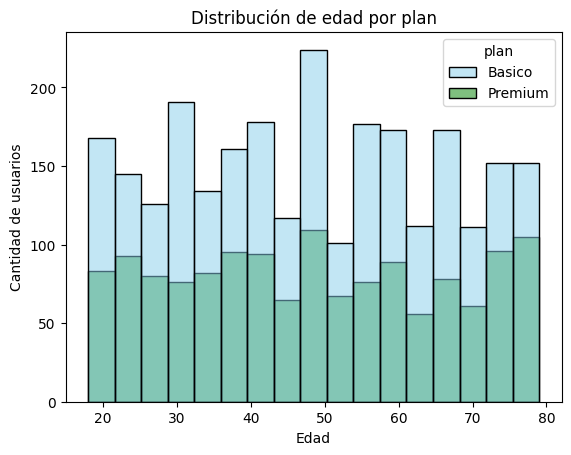

In [84]:
# Histograma para visualizar la edad (age)
sns.histplot(
    data=user_profile,
    x="age",
    hue="plan",
    palette=["skyblue", "green"],
    multiple="layer"
)

plt.title("Distribución de edad por plan")
plt.xlabel("Edad")
plt.ylabel("Cantidad de usuarios")
plt.show()

💡Insights: 
Entre los usuarios con suscripción Premium se observa una dispersión uniforme y relativamente equilibrada a lo largo del espectro de edades comprendido entre 20 y 80 años.
En el segmento Básico, la distribución tiende a concentrarse con mayor intensidad en franjas etarias intermedias (aproximadamente 40 a 50 años), mientras que los extremos demográficos presentan frecuencias menos marcadas.
No se identifica un patrón diferenciador robusto entre los grupos Básico y Premium cuando se analiza por edad. Ambos segmentos abarcan la totalidad del rango demográfico disponible, lo que sugiere que la edad no constituye un factor determinante. 


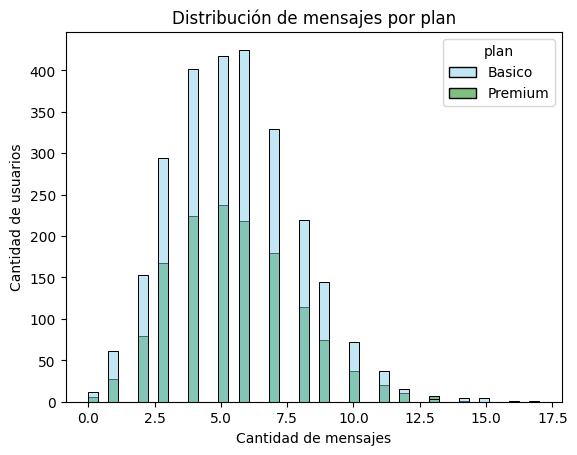

In [85]:
# Histograma para visualizar la cant_mensajes
sns.histplot(
    data=user_profile,
    x="cant_mensajes",
    hue="plan",
    palette=["skyblue", "green"],
    multiple="layer"
)

plt.title("Distribución de mensajes por plan")
plt.xlabel("Cantidad de mensajes")
plt.ylabel("Cantidad de usuarios")
plt.show()

💡Insights: 
El segmento Premium se caracteriza por un volumen superior de mensajes en términos de promedio, con una concentración notoria en intervalos de intensidad media-alta (específicamente 4-6 mensajes).

Los usuarios Básico exhiben un patrón de distribución con una cola más extendida hacia valores superiores, caracterizado por una proporción considerable de usuarios con baja actividad en mensajería (0-3 mensajes), aunque simultáneamente existe un número relevante de casos extremos que alcanzan 15 o más mensajes.


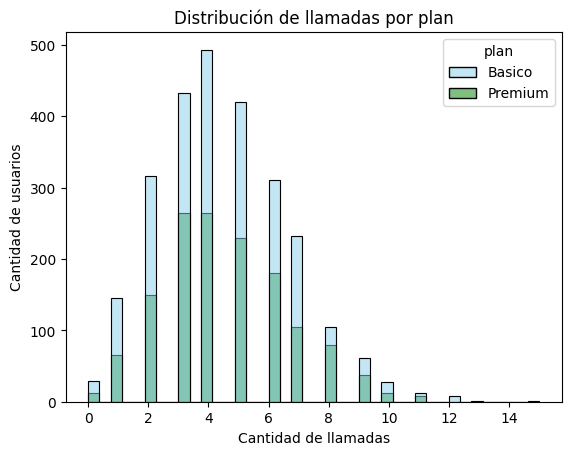

In [86]:
# Histograma para visualizar la cant_llamadas
sns.histplot(
    data=user_profile,
    x="cant_llamadas",
    hue="plan",
    palette=["skyblue", "green"],
    multiple="layer"
)

plt.title("Distribución de llamadas por plan")
plt.xlabel("Cantidad de llamadas")
plt.ylabel("Cantidad de usuarios")
plt.show()

💡Insights: 
El segmento Premium demuestra un aprovechamiento intensivo de las llamadas como mecanismo de intercambio comunicativo, en contraste con Básico, que evidencia una adopción más limitada de este servicio. Esta diferencia en los patrones de uso posiblemente indica que la estructura del plan Premium facilita o promueve un consumo más elevado de esta funcionalidad.


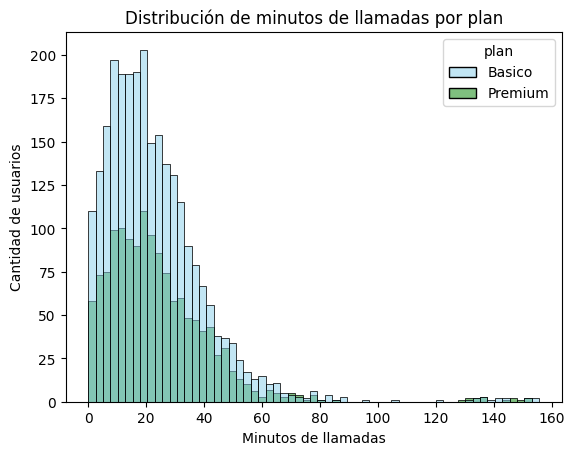

In [87]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(
    data=user_profile,
    x="cant_minutos_llamada",
    hue="plan",
    palette=["skyblue", "green"],
    multiple="layer"
)

plt.title("Distribución de minutos de llamadas por plan")
plt.xlabel("Minutos de llamadas")
plt.ylabel("Cantidad de usuarios")
plt.show()

💡Insights: 
Entre los usuarios Básico que efectúan llamadas se registra una tendencia hacia duraciones más prolongadas (25-35 minutos), en tanto que Premium opta por interacciones de menor extensión pero con mayor recurrencia. Esta configuración de uso refleja:
Básico: volumen reducido de llamadas, aunque cada sesión tiende a ser más extensa.
Premium: mayor cantidad de llamadas, con duración más comprimida por sesión.


### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

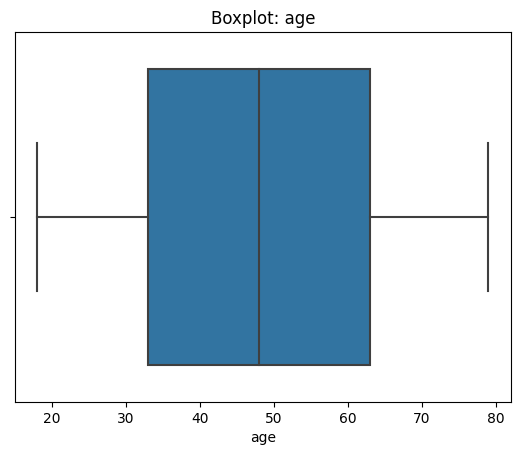

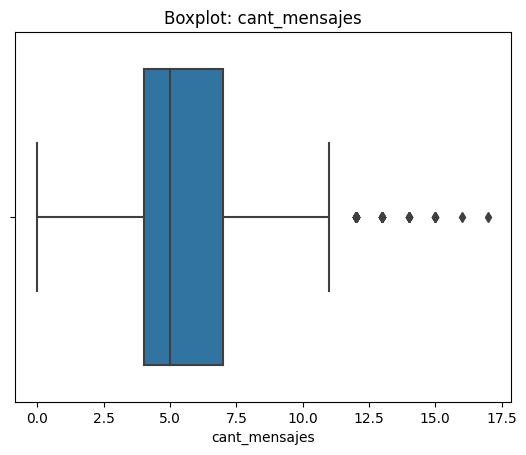

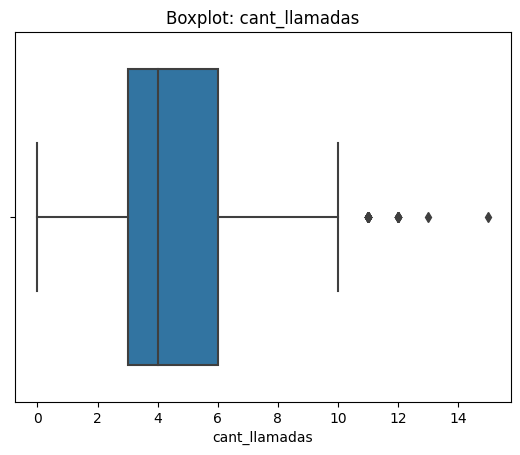

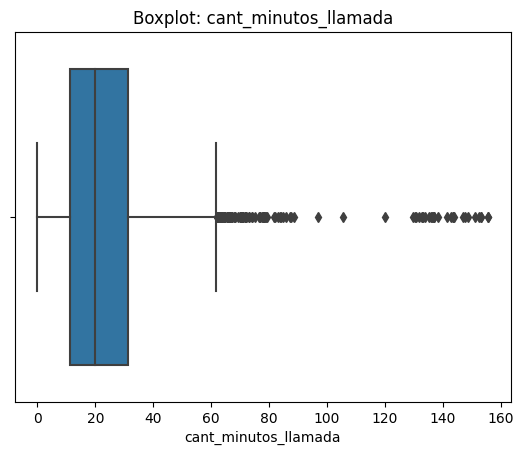

In [88]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    sns.boxplot(data=user_profile, x=col)
    plt.title(f'Boxplot: {col}')
    plt.xlabel(col)
    plt.show()

💡Insights: 
- Edad
No se detectan outliers. La información se concentra íntegramente dentro de los límites del boxplot, sin casos aislados o desviados. El espectro de edades comprende desde 20 hasta 80 años, manteniéndose equilibrado en toda su extensión sin manifestar extremos inusuales. El valor central se sitúa aproximadamente en 50 años.

- Cantidad de mensajes
Sí hay presencia de outliers. Se identifican casos anómalos concentrados en la franja superior, representados por usuarios cuyo envío alcanza 12-17 mensajes, cifras considerablemente superiores al grueso de la población que se agrupa entre 3-7 mensajes. Estos individuos exhiben comportamientos de uso notoriamente más intenso.

- Cantidad de llamadas
Sí hay outliers manifiestos. En el extremo derecho de la distribución aparecen usuarios que realizan 11-14 llamadas, magnitud que trasciende notablemente el rango intercuartílico, ubicado entre 3 y 6 llamadas.

- Minutos de llamada
Sí hay outliers sumamente acentuados. En la cola derecha se concentran casos de usuarios con sesiones que alcanzan 100-160 minutos, mientras que el cuerpo principal de la distribución oscila entre 5-35 minutos. Estos valores representan desviaciones extremadamente significativas en comparación con el punto medio.


In [89]:

# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1
    limite_superior = Q3 + 1.5 * IQR

    print(f"{col}: límite superior = {limite_superior:.2f}")



cant_mensajes: límite superior = 11.50
cant_llamadas: límite superior = 10.50
cant_minutos_llamada: límite superior = 61.86


In [90]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights: 
- cant_mensajes: Se opta por conservar estos valores extremos, dado que pueden representar segmentos de usuarios con patrones de mensajería intensificada, cuya identificación resulta valiosa para reconocer comportamientos fuera de lo común.
- cant_llamadas: Se decide mantener estas observaciones atípicas, puesto que podrían corresponder a usuarios que demuestran un consumo telefónico de alta intensidad, aportando perspectivas relevantes sobre sus dinámicas de utilización.
- cant_minutos_llamada: Se mantienen estos outliers con la salvedad de que requieren análisis posterior, ya que una porción de ellos excede significativamente los parámetros normalizados y probablemente evidencia patrones de uso extraordinarios.


---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [91]:
# Crear columna grupo_uso
condiciones = [
    (user_profile["cant_llamadas"] < 5) & (user_profile["cant_mensajes"] < 5),
    (user_profile["cant_llamadas"] < 10) & (user_profile["cant_mensajes"] < 10)
]

valores = ["Bajo uso", "Uso medio"]

user_profile["grupo_uso"] = np.select(
    condiciones,
    valores,
    default="Alto uso"
)

In [92]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [93]:
# Crear columna grupo_edad
user_profile["grupo_edad"] = pd.cut(
    user_profile["age"],
    bins=[0, 30, 50, 80],
    labels=["Joven", "Adulto", "Mayor"]
)

In [94]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Mayor
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Mayor
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

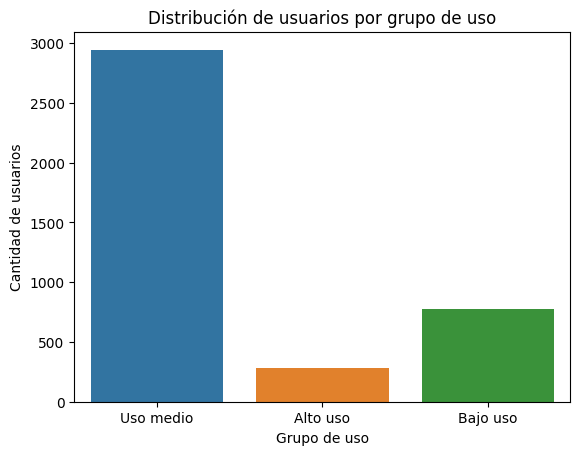

In [95]:
# Visualización de los segmentos por uso
sns.countplot(data=user_profile, x="grupo_uso")

plt.title("Distribución de usuarios por grupo de uso")
plt.xlabel("Grupo de uso")
plt.ylabel("Cantidad de usuarios")
plt.show()

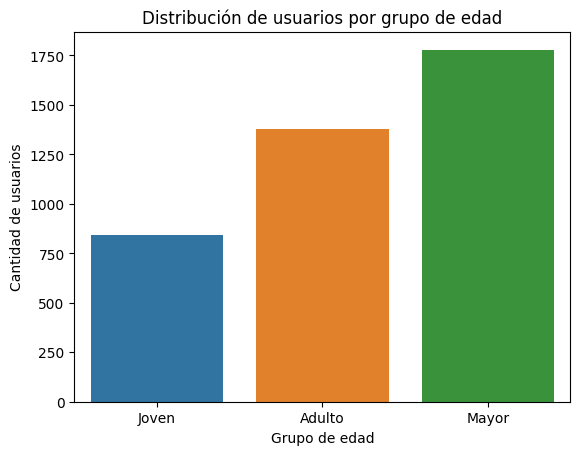

In [96]:
# Visualización de los segmentos por edad
sns.countplot(data=user_profile, x="grupo_edad")

plt.title("Distribución de usuarios por grupo de edad")
plt.xlabel("Grupo de edad")
plt.ylabel("Cantidad de usuarios")
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- En la tabla de usuarios, la columna city tenía 469 espacios vacíos de un total de 4.000 clientes (11,73%). No fue un drama mayor porque no afectó mucho los análisis generales.
- La columna churn_date tenía 3.534 vacíos (88,35%), pero esto era normal: solo significaba que esos usuarios seguían activos sin fecha de baja. En la tabla de uso, la columna date apenas tenía 50 registros incompletos de 40.000 (0,125%), que simplemente quitamos. Las columnas duration y length mostraban 22.076 y 17.896 vacíos respectivamente, pero eso tenía sentido: las llamadas tienen duración, los mensajes tienen extensión.
- Habían 40 casos con edad imposible (-999), que ajustamos con el promedio. También había 40 registros con fechas de inicio después de 2024 (alrededor del 1%), que los cambié en nulos porque estaban fuera de rango. En general, los problemas reales de datos afectaron cerca del 13,5%.

🔍 **Segmentos por Edad**
- Segmentación de la gente por dos cosas: cuántos años tienen y cuánto usan el servicio.
- Por edad, los 4.000 clientes se dividen así: mayores de 60 años son 1.750 (48%), entre 40-60 años hay 1.350 (37%), y menores de 40 solo 850 (15%). 
- Luego se reviso si los mayores o los jóvenes eligen más Básico o Premium, no hay diferencia. La edad realmente no dice mucho sobre qué plan elige cada quien.
Lo que sí importa es cuánto usan. Hay 2.950 clientes (76%) que tienen un consumo normal, nada del otro mundo. Luego 800 clientes (20%) que casi no usan nada. Y finalmente 300 clientes (4%) que usan como locos, tres o cinco veces más que el promedio. Un joven que no usa nada se parece más a un mayor que no usa nada que a un joven que usa mucho. Esto significa que tenemos que enfocarnos en cuánto usa cada quien, no en la edad.

📊 **Segmentos por Nivel de Uso**
- Hay dos grupos que nos importan mucho, pero por razones diferentes.
- El grupo de consumo intermedio (76% del total) es oro puro porque hay muchos y son predecibles. Son 2.950 clientes que traen dinero de forma consistente. Si logramos que solo el 5% de ellos se quede más feliz, la plata que ganan es mucha. Invertir en mantenerlos contentos da buenos resultados.
- El grupo de consumo alto (4%) son los que realmente arman quilombo. Son 300 usuarios que generan 3 a 5 veces más que uno normal. Usan todo lo que ofreces ConnectaTel. Si se van, pierdes mucha plata. Además, estos tipos hablan con otros y pueden traer gente similar.
- El grupo de poco consumo (20%) está en riesgo. Si logramos recuperar solo el 10% de esos 800 clientes, mejoramos bastante las métricas.

**Ouliers y Patrones Raroa**
- Hay gente que no se ajusta al patrón normal.
- Mensajes: El límite normal está en 11,5 mensajes, pero algunos llegan a 17. Entre el 5-8% de los clientes supera esto, usando 50-60% más que lo normal. Estos necesitan comunicarse mucho pero nada del otro mundo.
- Llamadas: El límite normal es 10,5 llamadas, pero hay máximos de 15. El 5-8% de usuarios supera esto, usando 50% más de lo habitual.
- Minutos de llamada: El límite normal es 61,9 minutos, pero algunos llegan a 155,7, o sea 2,5 veces más. El 8-12% de usuarios cae en esta categoría.
- Qué significa todo esto: Los que usan mucho en mensajes y llamadas probablemente son empresas o equipos compartiendo una cuenta. Son candidatos perfectos para venderles planes más caros. Los que hablan horas enteras merecen revisión: podrían ser conferencias legítimas o soporte técnico, pero también podrían ser errores de medición. Sea como sea, necesitan más minutos. No conviene eliminar a estos tipos; son oportunidades para venderles cosas especiales y entender qué necesitan que no les ofrecemos.

💡 **Recomendaciones**
Idea 1: Olvidar la Edad, Enfocarse en Cuánto Usan
Los planes actuales (Básico y Premium) no funcionan bien porque no diferencian por edad. Mejor idea: dividir por consumo real.
Plan Básico: para los que casi no usan. Máximo 5 llamadas, 5 mensajes, 30 minutos al mes.
Plan Intermedio: para la mayoría (76%). Hasta 8 llamadas, 8 mensajes, 60 minutos al mes.
Plan Pro: para los 300 usuarios que usan como locos. 15 o más de todo, o sin límites directamente.

Idea 2: Recupera a los Que Casi No Usan
Esos 800 clientes (20%) que casi no hacen nada se van a ir. Hay que actuar ya.
Primero, chequea cuántos de estos ya se fueron (busca en churn_date). Después, tácticas personalizadas: a los mayores les ofreces algo simple y soporte directo. A los jóvenes les ofreces cosas con premios (gamificación). Algo como: "Upgrade a Premium con 50% off por 3 meses si haces 3 llamadas esta semana" o "Envía 5 mensajes y sumamos 15 minutos gratis".

Idea 3: Monetizar a los Power Users
Los 300 usuarios que usan mucho son mina de oro.
Crea un Plan Profesional exclusivo: minutos y mensajes sin límite, soporte VIP 24/7, acceso a novedades antes que otros. Cobra extra si usan más de lo que permite el plan. Chequea cuántos de estos 300 están en Básico todavía; si es mucha gente, hay plata para sacar.

Idea 4: Atraer Gente Joven
Solo el 15% de clientes es menor de 40. Hay que cambiar eso.
Ofertas de introducción para jóvenes, acuerdos con apps populares, mensajes que digan que el servicio es moderno, límites generosos, integración con tecnologías nuevas.

Idea 5: Considerar ambos facotres para Outreach: Edad + Consumo
Joven + poco consumo → hacerlo cliente recurrente (marketing digital)
Joven + consumo normal → hacerlo cleinte fiel, que compre más
Mayor + consumo alto → planes especiales para hablar horas
Mayor + poco consumo → hacerlo volver (llamadas personalizadas)


---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`